## Exploratory Data Analysis

The notebooks in this project are designed to be reusable with other people's data as well.

### Copying Original Data

- `data/original/discord` should contain [exported Discord data](https://support.discord.com/hc/en-us/articles/360004027692-Requesting-a-Copy-of-your-Data). If copied correctly, `data/original/discord/Messages/index.json` should exist, alongside a number of channels and their messages like `data/original/discord/Messages/c12345/messages.json`.
- `data/original/reddit` should contain [exported Reddit data](https://support.reddithelp.com/hc/en-us/articles/360043048352-How-do-I-request-a-copy-of-my-Reddit-data-and-information). If copied correctly, `data/original/reddit/comments.csv` should exist.

### Preparing Anonymized / Aggregated Data

1. Python imports

In [22]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

ORIGINAL_BASE = os.path.join("data", "original")
ANONYMIZED_BASE = os.path.join("data", "anonymized")
ORIGINAL_DISCORD = os.path.join(ORIGINAL_BASE, "discord")
ORIGINAL_REDDIT = os.path.join(ORIGINAL_BASE, "reddit")
ANONYMIZED_DISCORD = os.path.join(ANONYMIZED_BASE, "discord")
ANONYMIZED_REDDIT = os.path.join(ANONYMIZED_BASE, "reddit")

print("Imports successful.")

Imports successful.


2. Find channels

In [5]:
discord_index_path = os.path.join(ORIGINAL_DISCORD, "messages", "index.json")

with open(discord_index_path, 'r', encoding='utf-8') as f:
    discord_index_data = json.load(f)

print(f"{len(discord_index_data)} channels/DMs found in Discord data.")

1382 channels/DMs found in Discord data.


3. Anonymize channel IDs

In [19]:
discord_channel_mapping = []
discord_id_to_anon_map = {}

for i, (original_id, name) in enumerate(discord_index_data.items(), start=1):
    discord_id_to_anon_map[original_id] = i
    discord_channel_mapping.append({
        'original_id': original_id,
        'anonymized_id': i,
        'name': name
    })

df_discord_channels = pd.DataFrame(discord_channel_mapping)
df_discord_channels.to_csv(os.path.join(ANONYMIZED_DISCORD, "mapped_channels.csv"), index=False)

print("Saved discord/mapped_channels.csv")

Saved discord/mapped_channels.csv


4. Load and sort all messages

In [ ]:
all_discord_messages = []
for original_id, anon_id in discord_id_to_anon_map.items():
    # Folders are prefixed with 'c' followed by the ID
    channel_folder = os.path.join(ORIGINAL_DISCORD, "Messages", f'c{original_id}')
    msg_file_path = os.path.join(channel_folder, 'messages.json')
    
    if os.path.exists(msg_file_path):
        with open(msg_file_path, 'r', encoding='utf-8') as f:
            messages = json.load(f)
            for m in messages:
                # Keep track of the anonymized channel context for later
                m['anon_channel_id'] = anon_id
                all_discord_messages.append(m)
    else:
        # Comment: Skipping channel ID {original_id} as messages.json was not found in directory
        continue

# Convert to objects for sorting and processing
for m in all_discord_messages:
    # Parse timestamp: assuming format "2025-05-01 11:19:32"
    m['dt_object'] = datetime.strptime(m['Timestamp'], '%Y-%m-%d %H:%M:%S')

# Sort all messages by date, oldest first
all_discord_messages.sort(key=lambda x: x['dt_object'])

print(f"Loaded and sorted {len(all_discord_messages)} messages, oldest-first.")

Loaded and sorted 63515 messages, oldest-first.


5. Anonymize timestamps and save messages.csv

In [ ]:
discord_processed_messages = []
for i, m in enumerate(all_discord_messages, start=1):
    # Date anonymization: remove minutes/seconds
    anon_date = m['dt_object'].replace(minute=0, second=0).strftime('%Y-%m-%d %H:%M:%S')
    
    # Calculate message length and attachment status
    content = m.get('Contents', '')
    msg_length = len(content) if content is not None else 0
    
    attachments = m.get('Attachments', '')
    has_attachments = bool(attachments and str(attachments).strip())

    discord_processed_messages.append({
        'date': anon_date,
        'message_id': i,
        'channel_id': m['anon_channel_id'],
        'message_length': msg_length,
        'has_attachments': has_attachments
    })

df_discord_messages = pd.DataFrame(discord_processed_messages)
df_discord_messages.to_csv(os.path.join(ANONYMIZED_DISCORD, "messages.csv"), index=False)

print("Saved discord/messages.csv")

Saved discord/messages.csv


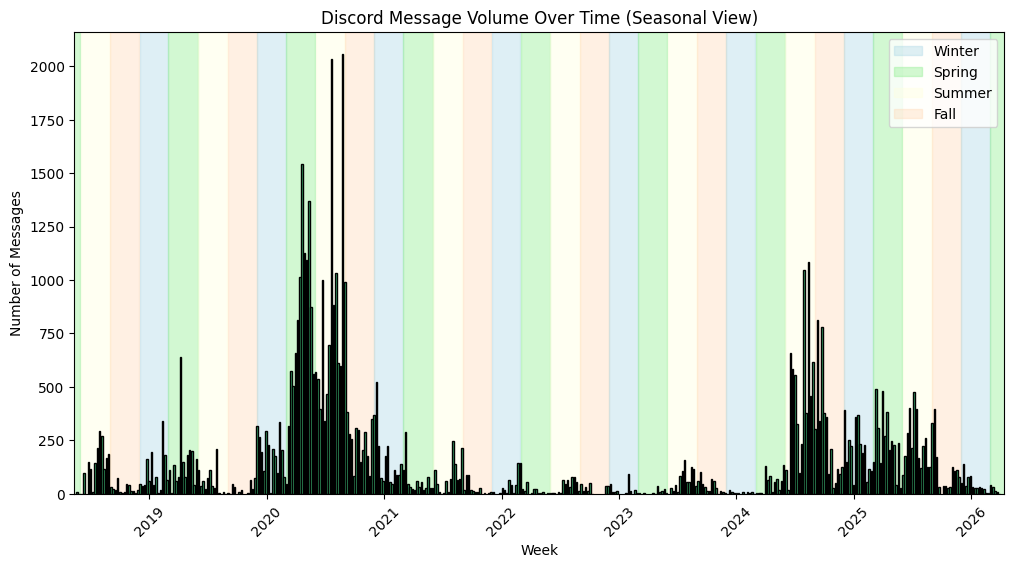

In [ ]:
# Convert the date column to datetime objects
df_discord_messages = pd.read_csv(os.path.join(ANONYMIZED_DISCORD, "messages.csv"))
df_discord_messages['date'] = pd.to_datetime(df_discord_messages['date'])

# Group by week
weekly_data = df_discord_messages.groupby(df_discord_messages['date'].dt.to_period('W')).size()
weeks = weekly_data.index.to_timestamp()
counts = weekly_data.values

plt.figure(figsize=(12, 6))

# Create the column (bar) chart, zorder ensures it stays above the background shading
plt.bar(weeks, counts, width=5, color='mediumseagreen', edgecolor='black', zorder=2)

# Determine the date range to apply background shading dynamically
min_date = df_discord_messages['date'].min()
max_date = df_discord_messages['date'].max()
start_year = min_date.year - 1
end_year = max_date.year + 1

# Define colors for each meteorological season
season_colors = {
    'Winter': 'lightblue',
    'Spring': 'lightgreen',
    'Summer': 'lightyellow',
    'Fall': 'peachpuff'
}

labels_added = set()

# Apply axvspan for each season across the spanned years
for year in range(start_year, end_year):
    # Meteorological seasons
    # Winter: Dec 1 (prev year) - Feb 28/29
    # Spring: Mar 1 - May 31
    # Summer: Jun 1 - Aug 31
    # Fall: Sep 1 - Nov 30
    seasons = [
        ('Winter', pd.Timestamp(year=year-1, month=12, day=1), pd.Timestamp(year=year, month=3, day=1) - pd.Timedelta(days=1)),
        ('Spring', pd.Timestamp(year=year, month=3, day=1), pd.Timestamp(year=year, month=6, day=1) - pd.Timedelta(days=1)),
        ('Summer', pd.Timestamp(year=year, month=6, day=1), pd.Timestamp(year=year, month=9, day=1) - pd.Timedelta(days=1)),
        ('Fall', pd.Timestamp(year=year, month=9, day=1), pd.Timestamp(year=year, month=12, day=1) - pd.Timedelta(days=1)),
    ]
    
    for name, start, end in seasons:
        # Only add a label for the legend once per season
        label = name if name not in labels_added else None
        plt.axvspan(start, end, color=season_colors[name], alpha=0.4, zorder=1, label=label)
        labels_added.add(name)

# Labels and Title
plt.xlabel('Week')
plt.ylabel('Number of Messages')
plt.title('Discord Message Volume Over Time')

# Limit the x-axis to the actual data range with a small buffer, rather than showing full unpopulated years
plt.xlim(min_date - pd.Timedelta(days=14), max_date + pd.Timedelta(days=14))

# Rotate x-axis labels and add legend
plt.xticks(rotation=45)

# Place legend outside or in a good location
plt.legend(loc='upper right')
plt.show()